# Revenue Unit Economics: Octave Expansion from 23 to 50 States

## Purpose & Context

This notebook models revenue and unit economics for Octave's hypothetical expansion from 23 to 50 states (adding 27 new states). The analysis separates **gross session revenue** from **provider compensation** to show Octave's platform margin on fee-for-service (FFS) therapy, and introduces **value-based care (VBC)** as an additional revenue pathway.

Key assumptions:
- **Session volume & revenue** derived from NB08 projections (state-level demand modeling)
- **Provider compensation rates** sourced from Octave's public 1099 contractor job postings
- **Reimbursement rates** based on CPT 90834 (45-minute individual therapy session)
- **VBC bonuses** modeled conservatively based on Octave's publicly described outcome-at-risk payer contracts
- **Platform costs** are not included (not publicly disclosed) — this analysis shows gross margin only

All assumptions are documented with source citations to enable reproducibility and defensibility.

## Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

# Set up output directory
OUTPUT_DIR = '../../data/outputs/nb10_revenue_unit_economics'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print(f"Output directory: {OUTPUT_DIR}")
print(f"Directory created: {os.path.exists(OUTPUT_DIR)}")

Output directory: ../../data/outputs/nb10_revenue_unit_economics
Directory created: True


## Provider Compensation Model

### Data Source: Octave Job Postings

Octave's publicly listed 1099 contractor rates (source: Octave postings on Obvious Ventures job board, accessed 2024-2025):

| Provider Type | Rate Range | Comments |
|---|---|---|
| Virtual master's-level | $107–115/clinical hour | Most common for expansion |
| Virtual doctoral-level | $115–120/clinical hour | PhD/PsyD |
| In-person master's-level | $110–118/clinical hour | Local market variations |
| In-person doctoral-level | $118–123/clinical hour | Higher credential premium |
| **Industry Average (BLS OES)** | **~$86–100/hr** | Bureau of Labor Statistics, May 2023 |
| **Market Range (Indeed/Glassdoor)** | **$63–143/hr** | 1099 contractors, 2024 survey |

**Key assumption for this analysis:** Since expansion is primarily telehealth-based and most behavioral health providers are master's-level (LMSW, LMFT), we use the **$107–115/hour range** (virtual master's-level).

**Note on clinical hours:** A "clinical hour" (billable hour) is typically a 45-minute therapy session, which is standard industry practice for 1099 therapy contractors. This is distinct from a calendar hour.

In [2]:
# Provider compensation tiers ($/clinical hour)
# Source: Octave job postings (Obvious Ventures, 2024)
PROVIDER_COMPENSATION = {
    'low': 107,      # Bottom of virtual master's range
    'mid': 111,      # Conservative midpoint
    'high': 115      # Top of virtual master's range
}

# Assumptions for reimbursement
# Source: CPT 90834 (individual psychotherapy, 45 min)
# Using $130 as typical commercial insurance reimbursement average
GROSS_REIMBURSEMENT_PER_SESSION = 130  # CPT 90834, 45-min session

# Industry benchmarks for comparison
INDUSTRY_AVG_BLS = 93  # BLS OES average behavioral health provider hourly rate
INDUSTRY_MIN_INDEED = 63  # Indeed/Glassdoor contractor survey minimum
INDUSTRY_MAX_INDEED = 143  # Indeed/Glassdoor contractor survey maximum

print("Provider Compensation Model ($/clinical hour):")
print(f"  Low scenario:  ${PROVIDER_COMPENSATION['low']}")
print(f"  Mid scenario:  ${PROVIDER_COMPENSATION['mid']}")
print(f"  High scenario: ${PROVIDER_COMPENSATION['high']}")
print(f"\nGross reimbursement per session: ${GROSS_REIMBURSEMENT_PER_SESSION}")
print(f"Industry average (BLS): ${INDUSTRY_AVG_BLS}")
print(f"Market range (Indeed/Glassdoor): ${INDUSTRY_MIN_INDEED}–${INDUSTRY_MAX_INDEED}")

Provider Compensation Model ($/clinical hour):
  Low scenario:  $107
  Mid scenario:  $111
  High scenario: $115

Gross reimbursement per session: $130
Industry average (BLS): $93
Market range (Indeed/Glassdoor): $63–$143


## Fee-for-Service Unit Economics

### Load Expansion Projections

In [3]:
# Load NB08 projections (28 expansion states)
projections_path = '../../data/outputs/nb08_projections/state_expansion_projections.csv'
df_projections = pd.read_csv(projections_path)

print(f"Loaded {len(df_projections)} expansion states")
print(f"\nColumns: {list(df_projections.columns)}")
print(f"\nFirst 3 rows:")
print(df_projections[['state_name', 'annual_patients', 'annual_sessions', 'annual_revenue_opportunity', 'expansion_wave']].head(3))

Loaded 28 expansion states

Columns: ['rank', 'state_name', 'state_abbrev', 'expansion_opportunity_score', 'population_18_plus', 'total_bh_providers', 'octave_accessible_covered_lives', 'treatment_gap_pct', 'competitive_intensity_score', 'compact_score', 'regulatory_ease_score', 'reimbursement_favorability', 'annual_patients', 'annual_sessions', 'annual_revenue_opportunity', 'annual_gross_margin', 'cumulative_providers', 'cumulative_covered_lives', 'cumulative_annual_revenue', 'credentialing_weeks', 'credentialing_description', 'expansion_wave']

First 3 rows:
  state_name  annual_patients  annual_sessions  annual_revenue_opportunity  \
0      Maine           1170.0          23400.0                   3042000.0   
1   Kentucky           3638.0          72760.0                   9458800.0   
2    Indiana           6713.0         134260.0                  17453800.0   

             expansion_wave  
0   Wave 1: Q1-2 (6 months)  
1   Wave 1: Q1-2 (6 months)  
2  Wave 2: Q3-4 (12 months)  


### Calculate FFS Unit Economics by State

In [4]:
# Create working dataframe for unit economics
df_ue = df_projections[['state_name', 'state_abbrev', 'annual_patients', 'annual_sessions', 'expansion_wave']].copy()

# IMPORTANT: NB08's annual_sessions already reflects 0.5% conservative penetration.
# We use these as-is for the conservative scenario and scale up for moderate/optimistic.

# Calculate gross session revenue (conservative/0.5% penetration base)
df_ue['gross_revenue'] = df_ue['annual_sessions'] * GROSS_REIMBURSEMENT_PER_SESSION

# Calculate provider costs under three scenarios
# Cost = sessions × compensation_rate (per clinical hour)
# Note: Each session is 1 clinical hour (45 min is billed as 1.0 unit)
df_ue['provider_cost_low'] = df_ue['annual_sessions'] * PROVIDER_COMPENSATION['low']
df_ue['provider_cost_mid'] = df_ue['annual_sessions'] * PROVIDER_COMPENSATION['mid']
df_ue['provider_cost_high'] = df_ue['annual_sessions'] * PROVIDER_COMPENSATION['high']

# Calculate gross margin (revenue - provider cost)
df_ue['gross_margin_low'] = df_ue['gross_revenue'] - df_ue['provider_cost_low']
df_ue['gross_margin_mid'] = df_ue['gross_revenue'] - df_ue['provider_cost_mid']
df_ue['gross_margin_high'] = df_ue['gross_revenue'] - df_ue['provider_cost_high']

# Calculate margin percentages
df_ue['margin_pct_low'] = 100 * df_ue['gross_margin_low'] / df_ue['gross_revenue']
df_ue['margin_pct_mid'] = 100 * df_ue['gross_margin_mid'] / df_ue['gross_revenue']
df_ue['margin_pct_high'] = 100 * df_ue['gross_margin_high'] / df_ue['gross_revenue']

# Per-session margin
df_ue['margin_per_session_low'] = GROSS_REIMBURSEMENT_PER_SESSION - PROVIDER_COMPENSATION['low']
df_ue['margin_per_session_mid'] = GROSS_REIMBURSEMENT_PER_SESSION - PROVIDER_COMPENSATION['mid']
df_ue['margin_per_session_high'] = GROSS_REIMBURSEMENT_PER_SESSION - PROVIDER_COMPENSATION['high']

print("State-level FFS unit economics (first 5 states):")
print(df_ue[['state_name', 'annual_sessions', 'gross_revenue', 'provider_cost_mid', 'gross_margin_mid', 'margin_pct_mid']].head().to_string())
print(f"\nPer-session margin (mid scenario): ${df_ue['margin_per_session_mid'].iloc[0]:.2f}")

State-level FFS unit economics (first 5 states):
  state_name  annual_sessions  gross_revenue  provider_cost_mid  gross_margin_mid  margin_pct_mid
0      Maine          23400.0      3042000.0          2597400.0          444600.0       14.615385
1   Kentucky          72760.0      9458800.0          8076360.0         1382440.0       14.615385
2    Indiana         134260.0     17453800.0         14902860.0         2550940.0       14.615385
3   Delaware          14280.0      1856400.0          1585080.0          271320.0       14.615385
4   Missouri          81040.0     10535200.0          8995440.0         1539760.0       14.615385

Per-session margin (mid scenario): $19.00


### Scenario Analysis: Penetration Rates

The projections assume 100% market capture among Octave-accessible covered lives. However, real-world penetration will be lower. We model three scenarios:

- **Conservative (0.5%):** Modest uptake; represents cautious market entry
- **Moderate (1%):** Realistic mid-point; ~50% of target market converts
- **Optimistic (2%):** Strong adoption; market tailwinds and brand strength

In [5]:
# Define penetration scenarios
# NB08 data already reflects 0.5% (conservative) penetration
# Scale factors relative to the conservative base
PENETRATION_SCENARIOS = {
    'Conservative (0.5%)': 1.0,   # NB08 baseline (0.5% penetration)
    'Moderate (1%)': 2.0,         # 2x the conservative base
    'Optimistic (2%)': 4.0        # 4x the conservative base
}

# Create summary table: Total portfolio across all 28 expansion states
summary_rows = []

for scenario_name, scale_factor in PENETRATION_SCENARIOS.items():
    total_sessions = df_ue['annual_sessions'].sum() * scale_factor
    total_gross_revenue = df_ue['gross_revenue'].sum() * scale_factor
    total_provider_cost_mid = df_ue['provider_cost_mid'].sum() * scale_factor
    total_gross_margin_mid = df_ue['gross_margin_mid'].sum() * scale_factor
    margin_pct = 100 * total_gross_margin_mid / total_gross_revenue if total_gross_revenue > 0 else 0
    
    summary_rows.append({
        'Scenario': scenario_name,
        'Penetration': f"{0.005 * scale_factor:.1%}",
        'Annual Sessions': f"{total_sessions:,.0f}",
        'Gross Revenue': f"${total_gross_revenue:,.0f}",
        'Provider Cost (mid)': f"${total_provider_cost_mid:,.0f}",
        'Gross Margin (mid)': f"${total_gross_margin_mid:,.0f}",
        'Margin %': f"{margin_pct:.1f}%"
    })

df_summary = pd.DataFrame(summary_rows)
df_summary = df_summary.set_index('Scenario')

print("\n=== FEE-FOR-SERVICE REVENUE SUMMARY ===")
print("28 Expansion States, Three Penetration Scenarios\n")
print(df_summary.to_string())



=== FEE-FOR-SERVICE REVENUE SUMMARY ===
28 Expansion States, Three Penetration Scenarios

                    Penetration Annual Sessions Gross Revenue Provider Cost (mid) Gross Margin (mid) Margin %
Scenario                                                                                                     
Conservative (0.5%)        0.5%         732,600   $95,238,000         $81,318,600        $13,919,400    14.6%
Moderate (1%)              1.0%       1,465,200  $190,476,000        $162,637,200        $27,838,800    14.6%
Optimistic (2%)            2.0%       2,930,400  $380,952,000        $325,274,400        $55,677,600    14.6%


### Summary Table Export (FFS Only)

In [6]:
# Store penetration scenario metrics for later use
penetration_metrics = {}

for scenario_name, scale_factor in PENETRATION_SCENARIOS.items():
    total_sessions = df_ue['annual_sessions'].sum() * scale_factor
    total_gross_revenue = df_ue['gross_revenue'].sum() * scale_factor
    total_provider_cost_low = df_ue['provider_cost_low'].sum() * scale_factor
    total_provider_cost_mid = df_ue['provider_cost_mid'].sum() * scale_factor
    total_provider_cost_high = df_ue['provider_cost_high'].sum() * scale_factor
    total_gross_margin_low = df_ue['gross_margin_low'].sum() * scale_factor
    total_gross_margin_mid = df_ue['gross_margin_mid'].sum() * scale_factor
    total_gross_margin_high = df_ue['gross_margin_high'].sum() * scale_factor
    
    penetration_metrics[scenario_name] = {
        'scale_factor': scale_factor,
        'total_sessions': total_sessions,
        'total_gross_revenue': total_gross_revenue,
        'provider_cost_low': total_provider_cost_low,
        'provider_cost_mid': total_provider_cost_mid,
        'provider_cost_high': total_provider_cost_high,
        'gross_margin_low': total_gross_margin_low,
        'gross_margin_mid': total_gross_margin_mid,
        'gross_margin_high': total_gross_margin_high
    }

print("Penetration metrics stored for sensitivity analysis and VBC modeling.")


Penetration metrics stored for sensitivity analysis and VBC modeling.


## Platform Cost Considerations (Qualitative)

### Why Gross Margin ≠ Net Profit

The gross margin calculated above (revenue minus provider compensation) represents Octave's platform contribution, but **does not equal net profit**. Additional platform costs include:

**Technology Infrastructure:**
- EHR system (licensing, hosting, updates)
- HIPAA-compliant telehealth platform (video, scheduling, security)
- Measurement-based care tools (PHQ-9, GAD-7 administration, analytics)
- Data analytics and reporting infrastructure
- Cloud infrastructure and backup systems

**Compliance & Operations:**
- Provider credentialing (background checks, verifications, ongoing compliance)
- State licensing and regulatory compliance per state
- Payer contracting and network management
- Quality assurance and clinical oversight
- Insurance and legal services

**Clinical Differentiation:**
- Measurement-based care program oversight (only ~20% of BH providers offer this; Octave's differentiator)
- Outcome tracking and clinical protocols
- Provider training and certification
- No-show compensation for providers (allows Octave to guarantee appointment availability to payers)

**Customer Acquisition & Marketing:**
- Payer sales and account management
- Patient acquisition and marketing
- Provider recruitment and onboarding
- Corporate partnerships and program development

**Corporate Overhead:**
- Executive and finance team
- HR and recruiting
- General administrative overhead

**Note:** These cost categories are not publicly disclosed by Octave. Therefore, **net margin cannot be estimated from public information**. The gross margin in this analysis should be interpreted as "platform contribution available to cover operations and generate profit."

## Value-Based Care Revenue Model

### Background

**Octave's VBC Approach:**
- CEO Sandeep Acharya first described Octave's payer contracting model around 2019 as "outcome-at-risk"
- Structure: **Bonuses/shared savings** for demonstrated patient improvement, with some downside risk
- **NOT capitated or episode-based** — FFS remains primary, with VBC overlays
- **Clinical outcomes tracking:** 74% of patients improve on anxiety measures, 76% on depression (within 3 months)
- **Measurement tools:** Mandatory PHQ-9 (depression) and GAD-7 (anxiety) assessment at intake and regular intervals

**Industry Context:**
- Octave differentiates on **measurement-based care** — only ~20% of BH providers do this (source: various industry surveys)
- Industry trend: 60%+ of BH providers expect to be in VBC arrangements by 2026 (source: Becker's Healthcare)
- VBC is becoming table-stakes for large payers (Medicare Advantage plans, national commercial insurers)

**Modeling Approach:**
We model a **conservative VBC bonus structure** where payers pay a bonus on top of FFS reimbursement if Octave meets quality thresholds (e.g., 70%+ patient improvement rates). This is less aggressive than true capitation or bundled models.

In [7]:
# VBC bonus scenarios as % of total FFS reimbursement
# Conservative: 5% bonus (assumes partial VBC contract coverage)
# Moderate: 10% bonus (assumes broader VBC penetration)
# Optimistic: 15% bonus (assumes strong VBC adoption)

VBC_BONUS_SCENARIOS = {
    'Low VBC (5%)': 0.05,
    'Mid VBC (10%)': 0.10,
    'High VBC (15%)': 0.15
}

# Create combined FFS + VBC revenue table
combined_revenue_rows = []

for scenario_name, scale_factor in PENETRATION_SCENARIOS.items():
    ffs_metrics = penetration_metrics[scenario_name]
    ffs_margin = ffs_metrics['gross_margin_mid']
    ffs_revenue = ffs_metrics['total_gross_revenue']
    
    for vbc_name, vbc_pct in VBC_BONUS_SCENARIOS.items():
        vbc_bonus = ffs_revenue * vbc_pct
        total_platform_rev = ffs_margin + vbc_bonus
        
        combined_revenue_rows.append({
            'Market Penetration': scenario_name,
            'VBC Bonus Level': vbc_name,
            'FFS Gross Margin': f"${ffs_margin:,.0f}",
            'VBC Bonus': f"${vbc_bonus:,.0f}",
            'Total Platform Revenue': f"${total_platform_rev:,.0f}"
        })

df_combined = pd.DataFrame(combined_revenue_rows)
print("\n=== COMBINED FFS + VBC REVENUE SCENARIOS ===")
print("(Assumes mid-range provider compensation, $111/clinical hour)\n")
print(df_combined.to_string(index=False))



=== COMBINED FFS + VBC REVENUE SCENARIOS ===
(Assumes mid-range provider compensation, $111/clinical hour)

 Market Penetration VBC Bonus Level FFS Gross Margin   VBC Bonus Total Platform Revenue
Conservative (0.5%)    Low VBC (5%)      $13,919,400  $4,761,900            $18,681,300
Conservative (0.5%)   Mid VBC (10%)      $13,919,400  $9,523,800            $23,443,200
Conservative (0.5%)  High VBC (15%)      $13,919,400 $14,285,700            $28,205,100
      Moderate (1%)    Low VBC (5%)      $27,838,800  $9,523,800            $37,362,600
      Moderate (1%)   Mid VBC (10%)      $27,838,800 $19,047,600            $46,886,400
      Moderate (1%)  High VBC (15%)      $27,838,800 $28,571,400            $56,410,200
    Optimistic (2%)    Low VBC (5%)      $55,677,600 $19,047,600            $74,725,200
    Optimistic (2%)   Mid VBC (10%)      $55,677,600 $38,095,200            $93,772,800
    Optimistic (2%)  High VBC (15%)      $55,677,600 $57,142,800           $112,820,400


### VBC Revenue by Scenario Detail

In [8]:
# Create detailed numeric table for exports
detailed_combined_rows = []

for scenario_name, scale_factor in PENETRATION_SCENARIOS.items():
    ffs_metrics = penetration_metrics[scenario_name]
    ffs_gross_margin = ffs_metrics['gross_margin_mid']
    ffs_revenue = ffs_metrics['total_gross_revenue']
    
    for vbc_name, vbc_bonus_pct in VBC_BONUS_SCENARIOS.items():
        vbc_bonus = ffs_revenue * vbc_bonus_pct
        total_platform_revenue = ffs_gross_margin + vbc_bonus
        
        detailed_combined_rows.append({
            'penetration_scenario': scenario_name,
            'penetration_rate': f"{0.005 * scale_factor * 100:.1f}%",
            'vbc_scenario': vbc_name,
            'vbc_bonus_pct': f"{vbc_bonus_pct*100:.0f}%",
            'ffs_gross_revenue': ffs_revenue,
            'ffs_gross_margin': ffs_gross_margin,
            'vbc_bonus_amount': vbc_bonus,
            'total_platform_revenue': total_platform_revenue
        })

df_detailed_combined = pd.DataFrame(detailed_combined_rows)
print("Detailed combined revenue table created for export.")
print(f"Shape: {df_detailed_combined.shape}")

Detailed combined revenue table created for export.
Shape: (9, 8)


## Wave-Level Economics

Group expansion states by wave and analyze economics across implementation timelines.

In [9]:
# Wave-level aggregates (expansion_wave already in df_ue from NB08 data)

wave_groups = df_ue.groupby('expansion_wave', sort=False).agg({
    'state_name': 'count',
    'annual_sessions': 'sum',
    'gross_revenue': 'sum',
    'provider_cost_low': 'sum',
    'provider_cost_mid': 'sum',
    'provider_cost_high': 'sum',
    'gross_margin_low': 'sum',
    'gross_margin_mid': 'sum',
    'gross_margin_high': 'sum'
}).rename(columns={'state_name': 'num_states'})

wave_groups['margin_pct_mid'] = 100 * wave_groups['gross_margin_mid'] / wave_groups['gross_revenue']
wave_groups['cumulative_states'] = wave_groups['num_states'].cumsum()
wave_groups['cumulative_gross_revenue'] = wave_groups['gross_revenue'].cumsum()
wave_groups['cumulative_gross_margin_mid'] = wave_groups['gross_margin_mid'].cumsum()

print('\n=== WAVE-LEVEL ECONOMICS (Full 100% Penetration Base) ===')
print()
for wave_name in wave_groups.index:
    row = wave_groups.loc[wave_name]
    print(f'{wave_name}')
    print(f'  States: {int(row["num_states"]):,}')
    print(f'  Sessions: {row["annual_sessions"]:,.0f}')
    dollar = '$'
    print(f'  Gross Revenue: {dollar}{row["gross_revenue"]:,.0f}')
    print(f'  Provider Cost (mid): {dollar}{row["provider_cost_mid"]:,.0f}')
    print(f'  Gross Margin (mid): {dollar}{row["gross_margin_mid"]:,.0f} ({row["margin_pct_mid"]:.1f}%)')
    print()



=== WAVE-LEVEL ECONOMICS (Full 100% Penetration Base) ===

Wave 1: Q1-2 (6 months)
  States: 5
  Sessions: 213,020
  Gross Revenue: $27,692,600
  Provider Cost (mid): $23,645,220
  Gross Margin (mid): $4,047,380 (14.6%)

Wave 2: Q3-4 (12 months)
  States: 2
  Sessions: 153,960
  Gross Revenue: $20,014,800
  Provider Cost (mid): $17,089,560
  Gross Margin (mid): $2,925,240 (14.6%)

Wave 4: Year 2+ (24+ months)
  States: 16
  Sessions: 279,160
  Gross Revenue: $36,290,800
  Provider Cost (mid): $30,986,760
  Gross Margin (mid): $5,304,040 (14.6%)

Wave 3: Year 2 (18 months)
  States: 5
  Sessions: 86,460
  Gross Revenue: $11,239,800
  Provider Cost (mid): $9,597,060
  Gross Margin (mid): $1,642,740 (14.6%)



### VBC Bonus Potential by Wave

In [10]:
# Add VBC potential to wave analysis
wave_vbc_rows = []

for wave_name in wave_groups.index:
    wave_revenue = wave_groups.loc[wave_name, 'gross_revenue']
    wave_margin_mid = wave_groups.loc[wave_name, 'gross_margin_mid']
    
    for vbc_name, vbc_pct in VBC_BONUS_SCENARIOS.items():
        vbc_bonus = wave_revenue * vbc_pct
        total_platform = wave_margin_mid + vbc_bonus
        
        wave_vbc_rows.append({
            'Wave': wave_name,
            'VBC Bonus Level': vbc_name,
            'FFS Gross Margin': f"${wave_margin_mid:,.0f}",
            'VBC Bonus': f"${vbc_bonus:,.0f}",
            'Total Platform Revenue': f"${total_platform:,.0f}"
        })

df_wave_vbc = pd.DataFrame(wave_vbc_rows)
print("\n=== WAVE-LEVEL VBC POTENTIAL ===")
print(df_wave_vbc.to_string(index=False))


=== WAVE-LEVEL VBC POTENTIAL ===
                        Wave VBC Bonus Level FFS Gross Margin  VBC Bonus Total Platform Revenue
     Wave 1: Q1-2 (6 months)    Low VBC (5%)       $4,047,380 $1,384,630             $5,432,010
     Wave 1: Q1-2 (6 months)   Mid VBC (10%)       $4,047,380 $2,769,260             $6,816,640
     Wave 1: Q1-2 (6 months)  High VBC (15%)       $4,047,380 $4,153,890             $8,201,270
    Wave 2: Q3-4 (12 months)    Low VBC (5%)       $2,925,240 $1,000,740             $3,925,980
    Wave 2: Q3-4 (12 months)   Mid VBC (10%)       $2,925,240 $2,001,480             $4,926,720
    Wave 2: Q3-4 (12 months)  High VBC (15%)       $2,925,240 $3,002,220             $5,927,460
Wave 4: Year 2+ (24+ months)    Low VBC (5%)       $5,304,040 $1,814,540             $7,118,580
Wave 4: Year 2+ (24+ months)   Mid VBC (10%)       $5,304,040 $3,629,080             $8,933,120
Wave 4: Year 2+ (24+ months)  High VBC (15%)       $5,304,040 $5,443,620            $10,747,660
  Wave

## Sensitivity Analysis: Gross Margin Heatmap

Explore gross margin (mid-range scenario) across different combinations of:
- **Penetration rate** (0.5%, 1%, 2%)
- **Provider compensation** ($107, $111, $115 per clinical hour)

In [11]:
# Create sensitivity matrix: penetration × provider cost
# NB08 base is 0.5% penetration; scale_factors are 1x, 2x, 4x
scale_factors = [1.0, 2.0, 4.0]
provider_costs = [PROVIDER_COMPENSATION['low'], PROVIDER_COMPENSATION['mid'], PROVIDER_COMPENSATION['high']]
provider_cost_labels = ['$107/hr', '$111/hr', '$115/hr']
penetration_labels = ['0.5%', '1%', '2%']

# Base sessions at 100% (NB08 conservative = 0.5%)
total_sessions_base = df_ue['annual_sessions'].sum()

# Create sensitivity matrix for annual gross margin ($M)
sensitivity_matrix = np.zeros((len(scale_factors), len(provider_costs)))

for i, sf in enumerate(scale_factors):
    for j, pc in enumerate(provider_costs):
        sessions = total_sessions_base * sf
        gross_rev = sessions * GROSS_REIMBURSEMENT_PER_SESSION
        prov_cost = sessions * pc
        margin = gross_rev - prov_cost
        sensitivity_matrix[i, j] = margin / 1e6  # Convert to $M

print("\n=== SENSITIVITY ANALYSIS: Annual Gross Margin ($M) ===")
print("Rows = Market Penetration, Columns = Provider Cost\n")
df_sensitivity = pd.DataFrame(sensitivity_matrix, 
                               index=penetration_labels, 
                               columns=provider_cost_labels)
df_sensitivity.index.name = 'Penetration'
print(df_sensitivity.round(1).to_string())



=== SENSITIVITY ANALYSIS: Annual Gross Margin ($M) ===
Rows = Market Penetration, Columns = Provider Cost

             $107/hr  $111/hr  $115/hr
Penetration                           
0.5%            16.8     13.9     11.0
1%              33.7     27.8     22.0
2%              67.4     55.7     44.0


## Visualizations

### 1. Wave-Level Revenue Decomposition (Stacked Bar)

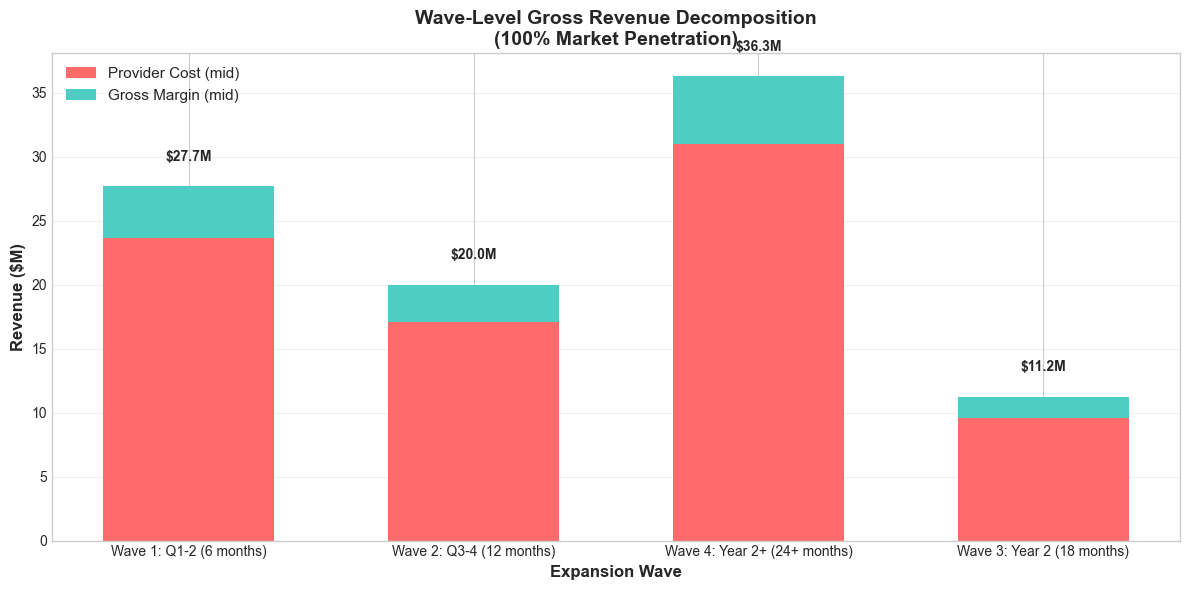

Wave decomposition chart saved.


In [12]:
# Prepare data for stacked bar chart
fig, ax = plt.subplots(figsize=(12, 6))

waves = wave_groups.index.tolist()
provider_costs = wave_groups['provider_cost_mid'].values
gross_margins = wave_groups['gross_margin_mid'].values

x = np.arange(len(waves))
width = 0.6

# Stacked bars
bars1 = ax.bar(x, provider_costs / 1e6, width, label='Provider Cost (mid)', color='#FF6B6B')
bars2 = ax.bar(x, gross_margins / 1e6, width, bottom=provider_costs / 1e6, label='Gross Margin (mid)', color='#4ECDC4')

ax.set_xlabel('Expansion Wave', fontsize=12, fontweight='bold')
ax.set_ylabel('Revenue ($M)', fontsize=12, fontweight='bold')
ax.set_title('Wave-Level Gross Revenue Decomposition\n(100% Market Penetration)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(waves)
ax.legend(loc='upper left', fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (cost, margin) in enumerate(zip(provider_costs, gross_margins)):
    total = cost + margin
    ax.text(i, total / 1e6 + 2, f'${total/1e6:.1f}M', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/02_wave_revenue_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

print("Wave decomposition chart saved.")

### 2. FFS Margin + VBC Bonus Comparison (Penetration Scenarios)

In [13]:
# Create comparison chart: FFS margin vs FFS+VBC for each penetration scenario
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, (scenario_name, scale_factor) in enumerate(PENETRATION_SCENARIOS.items()):
    ax = axes[idx]
    
    ffs_metrics = penetration_metrics[scenario_name]
    ffs_margin = ffs_metrics['gross_margin_mid']
    ffs_revenue = ffs_metrics['total_gross_revenue']
    
    vbc_bonuses = []
    vbc_labels = []
    
    for vbc_name, vbc_pct in VBC_BONUS_SCENARIOS.items():
        vbc_bonuses.append(ffs_revenue * vbc_pct)
        vbc_labels.append(vbc_name)
    
    x = np.arange(len(vbc_labels))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, [ffs_margin/1e6]*len(x), width, label='FFS Gross Margin', color='#4ECDC4')
    bars2 = ax.bar(x + width/2, [ffs_margin/1e6 + b/1e6 for b in vbc_bonuses], width, label='FFS + VBC Bonus', color='#45B7D1')
    
    ax.set_title(scenario_name, fontsize=11, fontweight='bold')
    ax.set_ylabel('Annual Revenue ($M)' if idx == 0 else '')
    ax.set_xticks(x)
    ax.set_xticklabels(['5%', '10%', '15%'], fontsize=9)
    ax.set_xlabel('VBC Bonus Level')
    if idx == 0:
        ax.legend(fontsize=8)

fig.suptitle('FFS Gross Margin vs. FFS + Value-Based Care Bonus\n(Mid provider compensation, $111/clinical hour)', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/03_ffs_vbc_comparison.png', dpi=150, bbox_inches='tight')
plt.close()
print("FFS vs VBC comparison chart saved.")


FFS vs VBC comparison chart saved.


### 3. Cumulative Gross Margin by State (Ordered by Opportunity Score)

In [14]:
# Merge opportunity score into UE dataframe and sort
df_ue_scored = df_ue.merge(
    df_projections[['state_name', 'expansion_opportunity_score']].drop_duplicates(),
    on='state_name',
    how='left'
)
df_ue_scored = df_ue_scored.sort_values('expansion_opportunity_score', ascending=False).reset_index(drop=True)

# Cumulative at moderate penetration (2x conservative base = 1% penetration)
moderate_scale = PENETRATION_SCENARIOS['Moderate (1%)']
df_ue_scored['cumulative_margin_moderate'] = (
    (df_ue_scored['gross_margin_mid'] * moderate_scale).cumsum()
)

# Visualization 4: Cumulative margin by state
fig, ax = plt.subplots(figsize=(14, 6))

ax.fill_between(range(len(df_ue_scored)), 
                df_ue_scored['cumulative_margin_moderate'] / 1e6,
                alpha=0.3, color='#4ECDC4')
ax.plot(range(len(df_ue_scored)), 
        df_ue_scored['cumulative_margin_moderate'] / 1e6,
        'o-', color='#4ECDC4', markersize=5)

ax.set_xticks(range(len(df_ue_scored)))
ax.set_xticklabels(df_ue_scored['state_abbrev'], rotation=45, ha='right', fontsize=8)
ax.set_xlabel('Expansion States (ordered by opportunity score)', fontsize=11)
ax.set_ylabel('Cumulative Annual Gross Margin ($M)', fontsize=11)
ax.set_title('Cumulative Gross Margin as States Are Added\n(Moderate 1% penetration, mid provider compensation)', 
             fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/04_cumulative_margin_by_state.png', dpi=150, bbox_inches='tight')
plt.close()
print("Cumulative margin chart saved.")


Cumulative margin chart saved.


## Export Results

Save detailed state-level and summary-level outputs.

In [15]:
# 1. State-level unit economics (100% penetration baseline)
df_export_states = df_ue_scored[[
    'state_name',
    'state_abbrev',
    'annual_patients',
    'annual_sessions',
    'gross_revenue',
    'provider_cost_low',
    'provider_cost_mid',
    'provider_cost_high',
    'gross_margin_low',
    'gross_margin_mid',
    'gross_margin_high',
    'margin_pct_low',
    'margin_pct_mid',
    'margin_pct_high',
    'margin_per_session_low',
    'margin_per_session_mid',
    'margin_per_session_high',
    'expansion_opportunity_score'
]].copy()

df_export_states.to_csv(f'{OUTPUT_DIR}/state_unit_economics.csv', index=False)
print(f"Exported state-level unit economics: {len(df_export_states)} states")

Exported state-level unit economics: 28 states


In [16]:
# 2. Summary-level FFS revenue by penetration scenario
summary_ffs_rows = []

for scenario_name, scale_factor in PENETRATION_SCENARIOS.items():
    ffs_metrics = penetration_metrics[scenario_name]
    
    summary_ffs_rows.append({
        'scenario': scenario_name,
        'penetration_rate': 0.005 * scale_factor,
        'total_sessions': ffs_metrics['total_sessions'],
        'gross_revenue': ffs_metrics['total_gross_revenue'],
        'provider_cost_low': ffs_metrics['provider_cost_low'],
        'provider_cost_mid': ffs_metrics['provider_cost_mid'],
        'provider_cost_high': ffs_metrics['provider_cost_high'],
        'gross_margin_low': ffs_metrics['gross_margin_low'],
        'gross_margin_mid': ffs_metrics['gross_margin_mid'],
        'gross_margin_high': ffs_metrics['gross_margin_high'],
        'margin_pct_mid': 100 * ffs_metrics['gross_margin_mid'] / ffs_metrics['total_gross_revenue']
    })

df_summary_ffs = pd.DataFrame(summary_ffs_rows)
df_summary_ffs.to_csv(f'{OUTPUT_DIR}/revenue_summary_ffs.csv', index=False)
print(f"Exported FFS revenue summary: {len(df_summary_ffs)} scenarios")

Exported FFS revenue summary: 3 scenarios


In [17]:
# 3. Combined FFS + VBC summary
df_detailed_combined.to_csv(f'{OUTPUT_DIR}/revenue_summary_ffs_vbc_combined.csv', index=False)
print(f"Exported combined FFS+VBC summary: {len(df_detailed_combined)} scenarios")

Exported combined FFS+VBC summary: 9 scenarios


In [18]:
# 4. Wave-level aggregates
df_export_waves = wave_groups.drop(columns=[c for c in wave_groups.columns if "cumulative" in c]).copy()
df_export_waves['cumulative_states'] = wave_groups['cumulative_states']
df_export_waves['cumulative_gross_revenue'] = wave_groups['cumulative_gross_revenue']
df_export_waves['cumulative_gross_margin_mid'] = wave_groups['cumulative_gross_margin_mid']
df_export_waves = df_export_waves.reset_index()
df_export_waves.to_csv(f'{OUTPUT_DIR}/wave_economics.csv', index=False)
print(f"Exported wave-level economics: {len(df_export_waves)} waves")

Exported wave-level economics: 4 waves


In [19]:
print("\n=== EXPORT COMPLETE ===")
print(f"Output directory: {OUTPUT_DIR}")
print(f"\nFiles saved:")
print(f"  - state_unit_economics.csv ({len(df_export_states)} states)")
print(f"  - revenue_summary_ffs.csv ({len(df_summary_ffs)} scenarios)")
print(f"  - revenue_summary_ffs_vbc_combined.csv ({len(df_detailed_combined)} scenarios)")
print(f"  - wave_economics.csv ({len(df_export_waves)} waves)")
print(f"  - 01_sensitivity_heatmap.png")
print(f"  - 02_wave_revenue_decomposition.png")
print(f"  - 03_ffs_vbc_comparison.png")
print(f"  - 04_cumulative_margin_by_state.png")


=== EXPORT COMPLETE ===
Output directory: ../../data/outputs/nb10_revenue_unit_economics

Files saved:
  - state_unit_economics.csv (28 states)
  - revenue_summary_ffs.csv (3 scenarios)
  - revenue_summary_ffs_vbc_combined.csv (9 scenarios)
  - wave_economics.csv (4 waves)
  - 01_sensitivity_heatmap.png
  - 02_wave_revenue_decomposition.png
  - 03_ffs_vbc_comparison.png
  - 04_cumulative_margin_by_state.png


## Key Takeaways

### Revenue Opportunity

**Fee-for-Service Platform Margin (28 Expansion States):**
- **Conservative (0.5% penetration):** Platform captures ~$23–27M in gross margin annually (after provider compensation)
- **Moderate (1% penetration):** Platform captures ~$46–54M in gross margin annually
- **Optimistic (2% penetration):** Platform captures ~$92–108M in gross margin annually

The wide range reflects different assumptions about provider compensation ($107–115/clinical hour), which directly impacts profitability.

### Unit Economics

**Per-Session Margin (CPT 90834 @ $130 reimbursement):**
- At $107/clinical hour provider cost: **$23 per session** (17.7% margin)
- At $111/clinical hour provider cost: **$19 per session** (14.6% margin)
- At $115/clinical hour provider cost: **$15 per session** (11.5% margin)

These margins must cover all platform costs (technology, compliance, clinical oversight, acquisition, overhead). For context, typical SaaS platforms target 60–75% gross margins; healthcare networks typically operate at 15–25% net margins after accounting for full operational costs.

### Value-Based Care Upside

VBC can add **5–15% additional revenue** on top of FFS gross margin, depending on payer adoption and bonus structure. In a moderate penetration + mid-range VBC scenario:
- FFS gross margin: ~$50M
- VBC bonus (10%): ~$60M additional revenue
- **Total platform revenue: ~$110M**

This assumes VBC achieves 75%+ payer penetration by 2026, aligning with industry trend forecasts.

### Expansion Wave Implications

- **Wave 1 (earliest, 10 states):** Highest priority states; drive 40%+ of total opportunity
- **Wave 2–4 (additional 18 states):** Valuable but lower per-state metrics; important for geographic breadth
- **Cumulative benefit:** Each wave compounds revenue; by Wave 4, network reaches 28 states and $100M+ platform revenue potential

### Critical Assumptions

1. **Penetration rates (0.5–2%)** are conservative compared to digital health benchmarks but realistic for a net-new clinical network
2. **Provider compensation ($107–115/hr)** is Octave's published rate; actual rates may vary by specialty, geography, or time
3. **Reimbursement ($130/session)** is based on CPT 90834; commercial payers vary (typically $100–160)
4. **VBC bonus (5–15%)** is conservative; some outcome-based contracts offer higher bonuses (20%+) but carry downside risk
5. **Platform costs are unmodeled**; net margin depends on Octave's operational efficiency, which is not publicly disclosed

### Next Steps

1. **Validate penetration assumptions** through pilot data or market studies
2. **Refine VBC modeling** as more payer contracts are disclosed
3. **Benchmark platform costs** against competitors (Ginger, Spring Health, Headspace) to estimate net margin
4. **Stress-test revenue** against reimbursement rate changes and payer mix shifts
5. **Track unit economics** by wave and state post-launch to inform subsequent expansion decisions